In [ ]:
from utils.attention_utils.attention_preprocessing_utils import AttentionPreprocessor
from utils.attention_utils.model import AngleAttentionLSTMTrainer
from utils.attention_utils.vizualisation_utils import *

In [2]:
attention_preprocessor = AttentionPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = attention_preprocessor.read_data()
sensors_df = attention_preprocessor.feature_selection()
attention_preprocessor.normalize_angle()
X = attention_preprocessor.group_and_pad(attention_preprocessor.sensor_df, group_col="Experiment_ID")[:,:,:]
Y = attention_preprocessor.group_and_pad(attention_preprocessor.target_df, group_col="Experiment_ID")[:,:-1,1:-1]

In [3]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import torch

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test (e.g., 80% train, 20% test)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [4]:
# Create trainer
trainer = AngleAttentionLSTMTrainer(
    input_size=X.shape[2],
    hidden_size=128,
    num_layers=2,
    output_size=Y.shape[2],
    num_angles=Y.shape[1]
)

model_path = "../../../../models/attention/attentionLSTM.joblib"

# Train model
# trainer.train(train_loader, test_loader, num_epochs=1, patience=10, save_path=model_path)

# Load best model
trainer.load(model_path)

# Predict
Y_pred, attn_weights = trainer.predict(X_tensor)


Model loaded from ../../../../models/attention/attentionLSTM.joblib


2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26, 28,  30,  32,  34,  36,  38,  39,  40,  41,  42,  49,  55,  56, 57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69, 70,  71,  72,  73,  74,  75,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88, 119, 124, 190, 193, 196, 199, 202, 205, 208, 211, 214, 217, 220, 223, 226, 229, 232, 235, 238, 241, 244, 245, 246, 253, 254, 255, 262, 265, 268, 271, 274, 277, 280, 285, 290, 293, 296, 299, 302, 305, 308, 311, 314

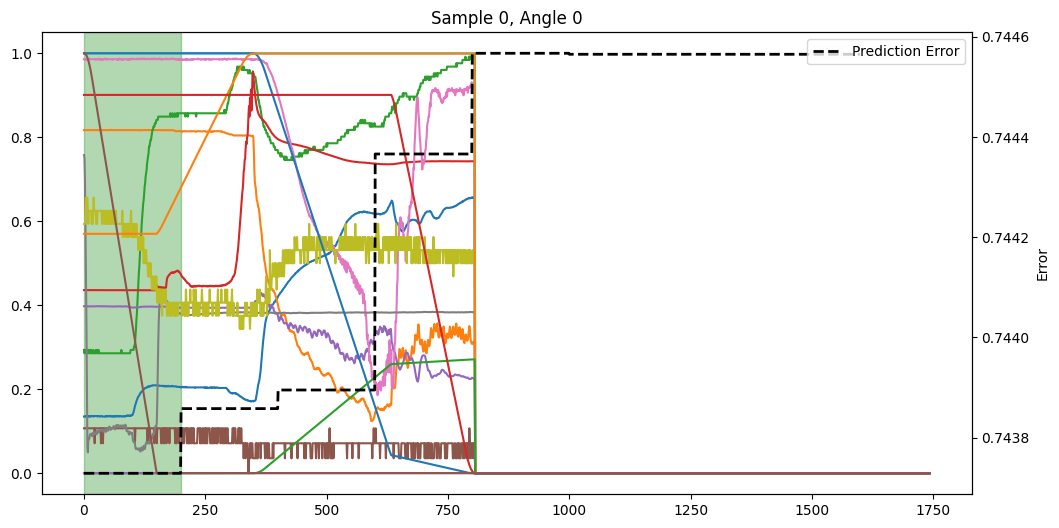

In [5]:
# Parameters
experiment_id, sample_idx = 2, 0
angle_idx = 0
patch_size = 200

# Compute and plot most accurate window
x_input = X[sample_idx]
y_true = Y[sample_idx, angle_idx]
window_errors, best_window = compute_window_errors(x_input, y_true, trainer.model, patch_size, angle_idx)
plot_features_with_error(x_input, window_errors, patch_size, best_window, num_features=X.shape[2],
                         title=f"Sample {sample_idx}, Angle {angle_idx}")

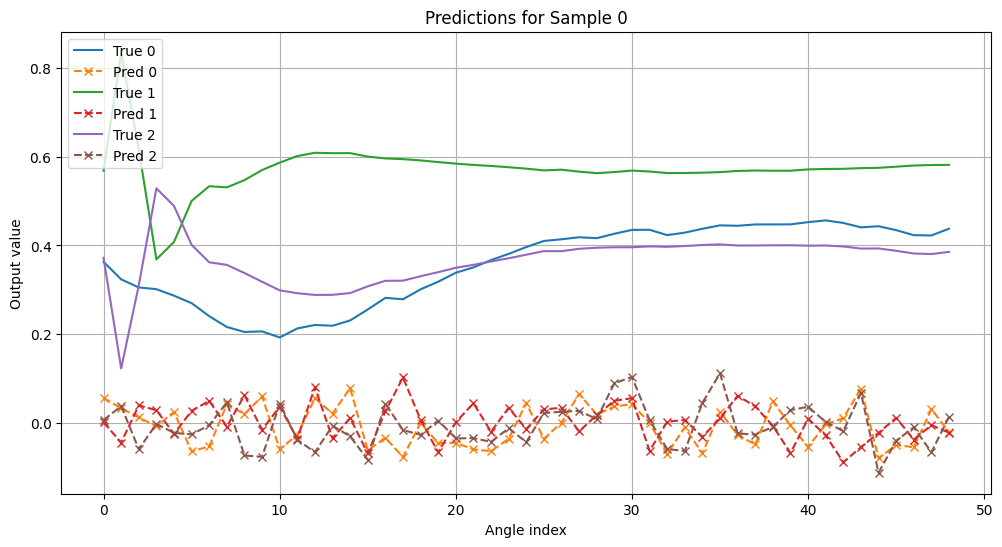

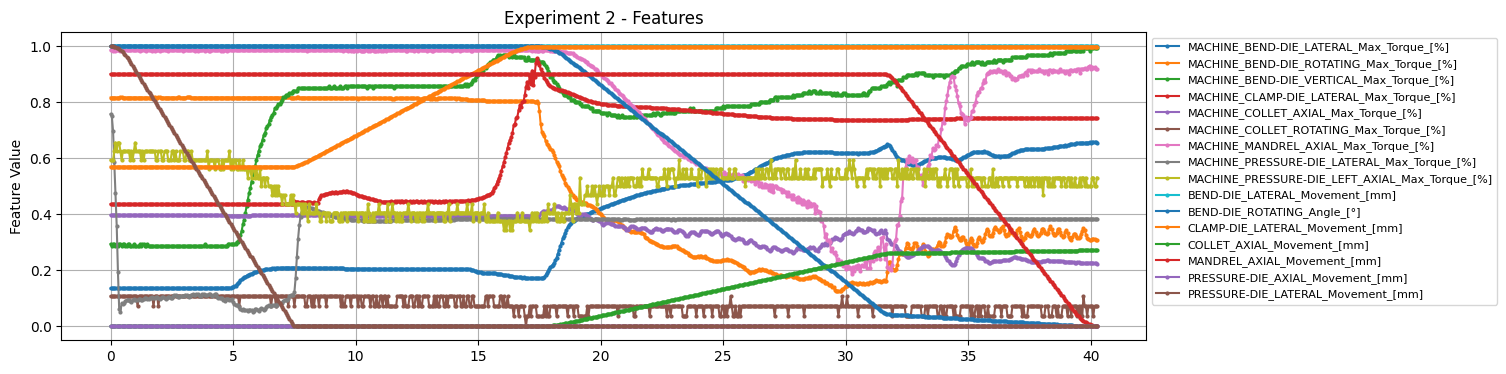

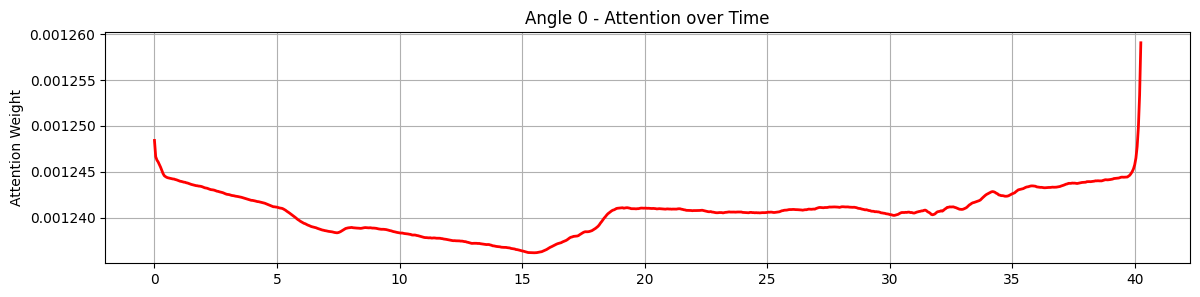

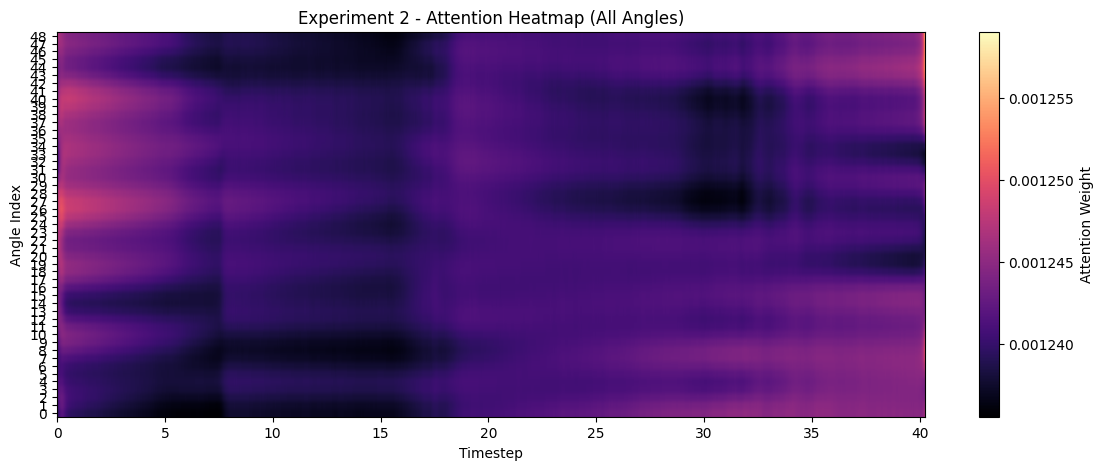

In [6]:
x_tensor = torch.tensor(x_input[np.newaxis, :, :], dtype=torch.float32)
with torch.no_grad():
    preds, _ = trainer.model(x_tensor)
preds = preds.cpu().numpy()[0]
plot_true_vs_pred(Y[sample_idx], preds, title=f"Predictions for Sample {sample_idx}")

# Visualize attention
visualize_attention(experiment_id, angle_idx, trainer.model, sensors_df)